## Imports

In [8]:
import os
import json
import numpy as np

## Config

In [ ]:
CFG = {                             ## dictionary containing the parameters of the simulation
    "root": "schelling_results",

    "L": 50,
    "occupied_fraction": 0.90,
    "runs_per_value": 10,
    "max_steps": 20,
    "record_every": 1,

    # "vn", "moore", "ext"
    "neighbourhood_type": "vn",
    "extended_radius": 2,  # only used if neighbourhood_type == "ext"

    "similar_values": np.linspace(0.0, 1.0, 101),

    "seed": 42,

    "checkpoint_every": 1,
    "resume": True,

    "save_frames": False,
}

## Folder Helpers

In [10]:
def sw_tag(x):
    return f"sw{format(x, '.3f').replace('.', 'p')}"



def neighbourhood_tag(cfg):
    if cfg["neighbourhood_type"] == "ext":
        return f"extR{cfg['extended_radius']}"
    return cfg["neighbourhood_type"]


def pct_tag(x):
    return format(float(x), ".3f").replace(".", "p")
    
def make_output_dir(cfg):
    path = os.path.join(
        cfg["root"],
        f"L{cfg['L']}",
        neighbourhood_tag(cfg),
        f"occ{pct_tag(cfg['occupied_fraction'])}"
    )
    os.makedirs(path, exist_ok=True)
    return path


def make_sw_dir(out_dir, sw):
    path = os.path.join(out_dir, f"sw{pct_tag(sw)}")
    os.makedirs(path, exist_ok=True)
    return path


def save_config(cfg, out_dir):
    cfg_save = dict(cfg)
    cfg_save["similar_values"] = [float(x) for x in cfg["similar_values"]]

    with open(os.path.join(out_dir, "cfg.json"), "w") as f:
        json.dump(cfg_save, f, indent=2)


def save_summary_csv(rows, path):
    if len(rows) == 0:
        return

    header = list(rows[0].keys())

    with open(path, "w") as f:
        f.write(",".join(header) + "\n")
        for row in rows:
            f.write(",".join(str(row[h]) for h in header) + "\n")

## Model

In [ ]:
class Schelling2DAsync:

    def __init__(
        self,
        L=50,
        occupied_fraction=0.90,
        similar_wanted=0.50,
        neighbourhood_type="vn",
        extended_radius=2,
        seed=None
    ):
        self.L = L
        self.N = L * L
        self.occupied_fraction = occupied_fraction
        self.similar_wanted = similar_wanted
        self.neighbourhood_type = neighbourhood_type
        self.extended_radius = extended_radius

        self.rng = np.random.default_rng(seed)
        self.offsets = self._make_offsets()
        self.grid = self._initialize_grid()

        self.percent_similar_history = []
        self.percent_unhappy_history = []
        self.moved_history = []
        self.frames = []

    def _initialize_grid(self):
        n_occ = int(round(self.occupied_fraction * self.N))
        n_empty = self.N - n_occ

        n_plus = n_occ // 2
        n_minus = n_occ - n_plus

        values = np.array(
            [1] * n_plus + [-1] * n_minus + [0] * n_empty,
            dtype=np.int8
        )

        self.rng.shuffle(values)
        return values.reshape((self.L, self.L))

    def _make_offsets(self):
        if self.neighbourhood_type == "vn":
            return [(-1, 0), (1, 0), (0, -1), (0, 1)]

        if self.neighbourhood_type == "moore":
            return [
                (di, dj)
                for di in (-1, 0, 1)
                for dj in (-1, 0, 1)
                if not (di == 0 and dj == 0)
            ]

        if self.neighbourhood_type == "ext":
            R = self.extended_radius
            return [
                (di, dj)
                for di in range(-R, R + 1)
                for dj in range(-R, R + 1)
                if not (di == 0 and dj == 0)
            ]

        raise ValueError("neighbourhood_type must be 'vn', 'moore', or 'ext'.")

    def local_fraction_similar(self, i, j, grid=None):
        if grid is None:
            grid = self.grid

        s = grid[i, j]

        if s == 0:
            return np.nan

        same = 0
        occupied = 0

        for di, dj in self.offsets:
            ni = (i + di) % self.L
            nj = (j + dj) % self.L
            val = grid[ni, nj]

            if val != 0:
                occupied += 1
                if val == s:
                    same += 1

        if occupied == 0:
            return 1.0

        return same / occupied

    def is_happy(self, i, j, grid=None):
        if grid is None:
            grid = self.grid

        if grid[i, j] == 0:
            return True

        return self.local_fraction_similar(i, j, grid) >= self.similar_wanted

    def occupied_sites(self):
        return [tuple(x) for x in np.argwhere(self.grid != 0)]

    def empty_sites(self):
        return [tuple(x) for x in np.argwhere(self.grid == 0)]

    def unhappy_agents(self):
        return [
            (i, j)
            for i, j in self.occupied_sites()
            if not self.is_happy(i, j)
        ]

    def toroidal_L1_distance(self, a, b):
        i1, j1 = a
        i2, j2 = b

        di = abs(i1 - i2)
        dj = abs(j1 - j2)

        di = min(di, self.L - di)
        dj = min(dj, self.L - dj)

        return di + dj

    def would_be_happy_at(self, source, target):
        si, sj = source
        ti, tj = target

        if self.grid[si, sj] == 0:
            return False

        if self.grid[ti, tj] != 0:
            return False

        temp = self.grid.copy()
        temp[ti, tj] = temp[si, sj]
        temp[si, sj] = 0

        return self.is_happy(ti, tj, temp)

    def best_target_for(self, source):
        valid = []

        for target in self.empty_sites():
            if self.would_be_happy_at(source, target):
                d = self.toroidal_L1_distance(source, target)
                valid.append((d, target))

        if len(valid) == 0:
            return None

        min_d = min(d for d, _ in valid)
        candidates = [target for d, target in valid if d == min_d]

        return candidates[self.rng.integers(len(candidates))]

    def compute_percent_similar(self):
        vals = [
            100.0 * self.local_fraction_similar(i, j)
            for i, j in self.occupied_sites()
        ]

        return float(np.mean(vals)) if vals else 0.0

    def compute_percent_unhappy(self):
        occ = len(self.occupied_sites())

        if occ == 0:
            return 0.0

        return 100.0 * len(self.unhappy_agents()) / occ

    def record(self, moved=0, save_frame=False):
        self.percent_similar_history.append(self.compute_percent_similar())
        self.percent_unhappy_history.append(self.compute_percent_unhappy())
        self.moved_history.append(moved)

        if save_frame:
            self.frames.append(self.grid.copy())

    def step(self):
        unhappy = self.unhappy_agents()

        if len(unhappy) == 0:
            return 0

        self.rng.shuffle(unhappy)
        moved = 0

        for source in unhappy:
            si, sj = source

            if self.grid[si, sj] == 0:
                continue

            if self.is_happy(si, sj):
                continue

            target = self.best_target_for((si, sj))

            if target is not None:
                ti, tj = target
                self.grid[ti, tj] = self.grid[si, sj]
                self.grid[si, sj] = 0
                moved += 1

        return moved

    

    def save_checkpoint(self, path, step):
        np.savez_compressed(
            path,
            grid=self.grid,
            step=step,
            percent_similar=np.array(self.percent_similar_history),
            percent_unhappy=np.array(self.percent_unhappy_history),
            moved=np.array(self.moved_history),
        )

    def load_checkpoint(self, path):
        data = np.load(path, allow_pickle=True)

        self.grid = data["grid"]
        self.percent_similar_history = list(data["percent_similar"])
        self.percent_unhappy_history = list(data["percent_unhappy"])
        self.moved_history = list(data["moved"])

        return int(data["step"])

    

    def run(
        self,
        max_steps=300,
        record_every=1,
        save_frames=False,
        checkpoint_path=None,
        checkpoint_every=None,
        start_step=0,
        verbose=False
    ):
        if start_step == 0 and len(self.percent_similar_history) == 0:
            self.record(moved=0, save_frame=save_frames)

        final_step = start_step

        for t in range(start_step + 1, max_steps + 1):
            moved = self.step()
            final_step = t

            if t % record_every == 0:
                self.record(moved=moved, save_frame=save_frames)

            if checkpoint_path is not None and checkpoint_every is not None:
                if t % checkpoint_every == 0:
                    self.save_checkpoint(checkpoint_path, step=t)

            if verbose:
                print(
                    f"t={t:4d} | moved={moved:4d} | "
                    f"sim={self.percent_similar_history[-1]:6.2f} | "
                    f"unhappy={self.percent_unhappy_history[-1]:6.2f}"
                )

            if moved == 0:
                break

        if checkpoint_path is not None:
            self.save_checkpoint(checkpoint_path, step=final_step)

        return {
            "final_grid": self.grid.copy(),
            "percent_similar": np.array(self.percent_similar_history),
            "percent_unhappy": np.array(self.percent_unhappy_history),
            "moved": np.array(self.moved_history),
            "frames": self.frames,
            "steps": final_step,
        }


## Saving Single Run

In [14]:
def save_run_results(path, results, similar_wanted, save_frames=False):
    if save_frames:
        np.savez_compressed(
            path,
            final_grid=results["final_grid"],
            percent_similar=results["percent_similar"],
            percent_unhappy=results["percent_unhappy"],
            moved=results["moved"],
            frames=np.array(results["frames"], dtype=np.int8),
            similar_wanted=similar_wanted,
            steps=results["steps"],
        )
    else:
        np.savez_compressed(
            path,
            final_grid=results["final_grid"],
            percent_similar=results["percent_similar"],
            percent_unhappy=results["percent_unhappy"],
            moved=results["moved"],
            similar_wanted=similar_wanted,
            steps=results["steps"],
        )

## Scan Function

In [12]:
def run_scan(cfg):
    out_dir = make_output_dir(cfg)
    save_config(cfg, out_dir)

    rows = []

    for sw in cfg["similar_values"]:
        sw_dir = os.path.join(out_dir, sw_tag(sw))
        os.makedirs(sw_dir, exist_ok=True)

        final_sim = []
        final_unhappy = []
        final_steps = []

        for run_id in range(cfg["runs_per_value"]):
            run_path = os.path.join(sw_dir, f"r{run_id:03d}.npz")
            chk_path = os.path.join(sw_dir, f"chk_r{run_id:03d}.npz")

            seed = None
            if cfg["seed"] is not None:
                seed = cfg["seed"] + run_id + int(round(10000 * sw))

            model = Schelling2DAsync(
                L=cfg["L"],
                occupied_fraction=cfg["occupied_fraction"],
                similar_wanted=sw,
                neighbourhood_type=cfg["neighbourhood_type"],
                extended_radius=cfg["extended_radius"],
                seed=seed
            )

            start_step = 0

            if cfg["resume"] and os.path.exists(chk_path):
                start_step = model.load_checkpoint(chk_path)
                print(f"Resuming sw={sw:.3f}, run={run_id}, step={start_step}")

            results = model.run(
                max_steps=cfg["max_steps"],
                record_every=cfg["record_every"],
                save_frames=cfg["save_frames"],
                checkpoint_path=chk_path,
                checkpoint_every=cfg["checkpoint_every"],
                start_step=start_step,
                verbose=False
            )

            save_run_results(
                run_path,
                results,
                similar_wanted=sw,
                save_frames=cfg["save_frames"]
            )

            final_sim.append(results["percent_similar"][-1])
            final_unhappy.append(results["percent_unhappy"][-1])
            final_steps.append(results["steps"])

        row = {
            "similar_wanted": float(sw),
            "avg_final_similar": float(np.mean(final_sim)),
            "std_final_similar": float(np.std(final_sim)),
            "avg_final_unhappy": float(np.mean(final_unhappy)),
            "std_final_unhappy": float(np.std(final_unhappy)),
            "avg_steps": float(np.mean(final_steps)),
            "std_steps": float(np.std(final_steps)),
        }

        rows.append(row)

        print(
            f"sw={sw:.3f} | "
            f"sim={row['avg_final_similar']:.2f} ± {row['std_final_similar']:.2f} | "
            f"unhappy={row['avg_final_unhappy']:.2f} | "
            f"steps={row['avg_steps']:.1f}"
        )

    save_summary_csv(rows, os.path.join(out_dir, "summary.csv"))

    return rows, out_dir

## Run Simulations

In [46]:
summary, output_folder = run_scan(CFG)

print("Saved in:")
print(output_folder)

sw=0.510 | sim=92.71 ± 0.00 | unhappy=0.00 | steps=16.0
Saved in:
schelling_results\L50\vn\occ0p900


## Time Evolution Plots

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def pct_tag(x):
    """
    Converts 0.900 into '0p900'.
    """
    return f"{float(x):.3f}".replace(".", "p")


def sw_tag(sw):
    """
    Converts 0.510 into 'sw0p510'.
    """
    return f"sw{pct_tag(sw)}"


def get_run_folder(
    L=50,
    neighbourhood_type="vn",
    empty_fraction=0.10,
    similar_wanted=0.51,
    root="schelling_results"
):
    
    occupied_fraction = 1.0 - empty_fraction

    folder = (
        Path(root)
        / f"L{L}"
        / neighbourhood_type
        / f"occ{pct_tag(occupied_fraction)}"
        / sw_tag(similar_wanted)
    )

    return folder


def load_time_series_from_folder(folder):
    
    folder = Path(folder)
    run_files = sorted(folder.glob("r*.npz"))

    if len(run_files) == 0:
        raise FileNotFoundError(f"No run files found in: {folder}")

    similar_series = []
    unhappy_series = []

    for file in run_files:
        data = np.load(file, allow_pickle=True)

        similar_series.append(data["percent_similar"])
        unhappy_series.append(data["percent_unhappy"])

    return similar_series, unhappy_series, run_files

def plot_mean_similar_and_unhappy_over_time(
    L=50,
    neighbourhood_type="vn",
    empty_fraction=0.10,
    similar_wanted=0.51,
    root="schelling_results",
    max_step_plot=None,
    save_fig=True,
    show_fig=True
):

    folder = get_run_folder(
        L=L,
        neighbourhood_type=neighbourhood_type,
        empty_fraction=empty_fraction,
        similar_wanted=similar_wanted,
        root=root
    )

    similar_series, unhappy_series, run_files = load_time_series_from_folder(folder)

    max_len = max(len(x) for x in similar_series)

    if max_step_plot is not None:
        max_len = min(max_len, max_step_plot + 1)

    similar_matrix = np.full((len(similar_series), max_len), np.nan)
    unhappy_matrix = np.full((len(unhappy_series), max_len), np.nan)

    for i, series in enumerate(similar_series):
        series = series[:max_len]
        similar_matrix[i, :len(series)] = series

    for i, series in enumerate(unhappy_series):
        series = series[:max_len]
        unhappy_matrix[i, :len(series)] = series

    mean_similar = np.nanmean(similar_matrix, axis=0)
    std_similar = np.nanstd(similar_matrix, axis=0)

    mean_unhappy = np.nanmean(unhappy_matrix, axis=0)
    std_unhappy = np.nanstd(unhappy_matrix, axis=0)

    if np.nanmax(mean_similar) <= 1.5:
        mean_similar *= 100
        std_similar *= 100

    if np.nanmax(mean_unhappy) <= 1.5:
        mean_unhappy *= 100
        std_unhappy *= 100

    steps = np.arange(max_len)

    plt.figure(figsize=(12, 7))

    plt.plot(
        steps,
        mean_similar,
        linewidth=3.5,
        label="Percentuale di vicini simili"
    )

    plt.fill_between(
        steps,
        mean_similar - std_similar,
        mean_similar + std_similar,
        alpha=0.2
    )

    plt.plot(
        steps,
        mean_unhappy,
        linewidth=3.5,
        label="Percentuale di agenti insoddisfatti"
    )

    plt.fill_between(
        steps,
        mean_unhappy - std_unhappy,
        mean_unhappy + std_unhappy,
        alpha=0.2
    )

    plt.xlabel("Step di aggiornamento", fontsize=22)
    plt.ylabel("Percentuale (%)", fontsize=22)
    plt.title("Evoluzione temporale del sistema", fontsize=26, pad=18)

    plt.xticks(np.arange(0, max_len, 1), fontsize=18)
    plt.yticks(np.arange(0, 101, 10), fontsize=18)

    plt.ylim(0, 100)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=18)

    plt.tight_layout()

    if save_fig:
        save_path = folder / "evoluzione_temporale_sistema.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved in: {save_path}")

    if show_fig:
        plt.show()
    else:
        plt.close()

Figure saved in: schelling_results\L50\vn\occ0p900\sw0p500\evoluzione_temporale_sistema.png


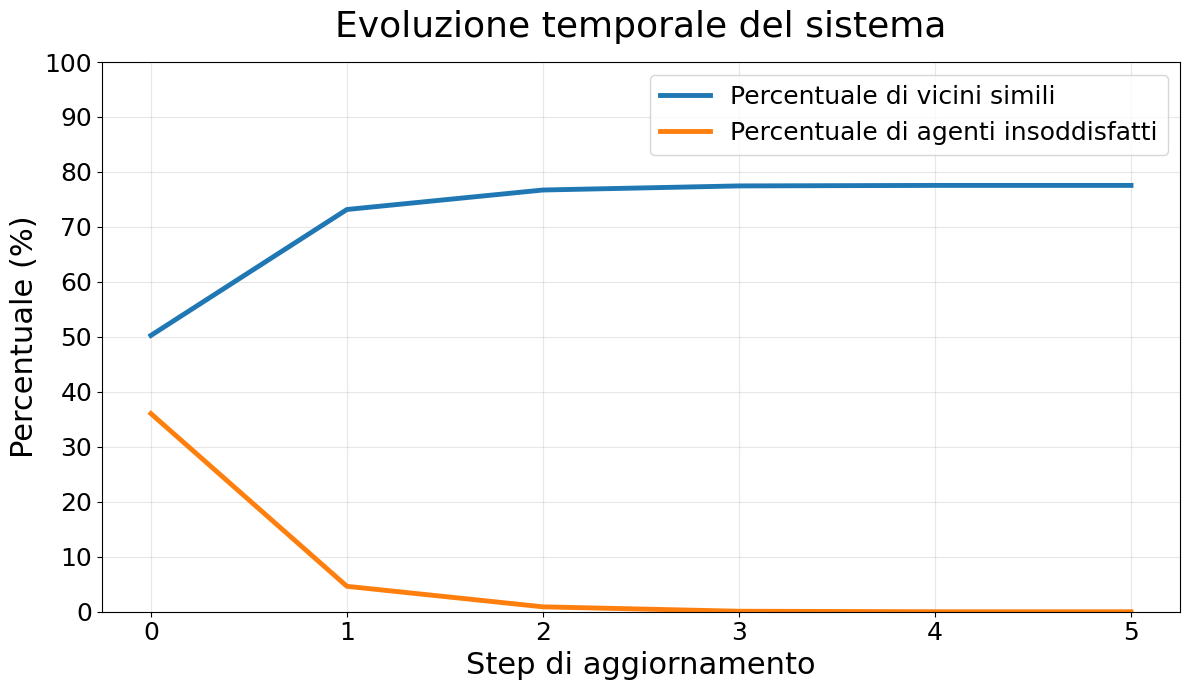

In [23]:
plot_mean_similar_and_unhappy_over_time(
    L=50,
    neighbourhood_type="vn",
    empty_fraction=0.10,
    similar_wanted=0.50,
    max_step_plot=5
)

Figure saved in: schelling_results\L50\vn\occ0p900\sw0p510\evoluzione_temporale_sistema.png


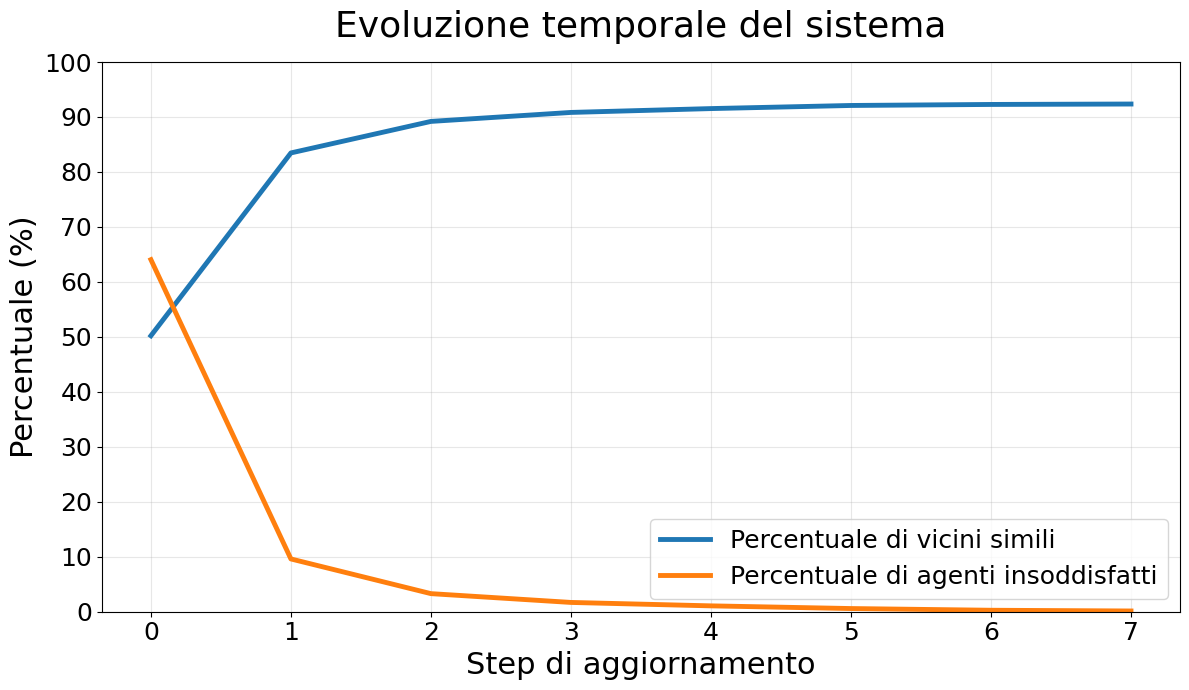

In [27]:
plot_mean_similar_and_unhappy_over_time(
    L=50,
    neighbourhood_type="vn",
    empty_fraction=0.10,
    similar_wanted=0.51,
    max_step_plot=7
)

## Phase-Transition-Like Behaviour

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def parse_sw_from_folder(folder_name):
   
    return float(folder_name.replace("sw", "").replace("p", "."))


def load_final_similarity_from_sw_folder(sw_folder):
    
    sw_folder = Path(sw_folder)
    run_files = sorted(sw_folder.glob("r*.npz"))

    if len(run_files) == 0:
        return None

    final_values = []

    for file in run_files:
        data = np.load(file, allow_pickle=True)

        final_similarity = data["percent_similar"][-1]
        final_values.append(final_similarity)

    final_values = np.array(final_values, dtype=float)

    if np.nanmax(final_values) <= 1.5:
        final_values *= 100

    return final_values

def plot_final_similarity_from_npz(
    output_folder,
    save_fig=True,
    show_fig=True
):
    
    output_folder = Path(output_folder)

    sw_folders = sorted(
        [p for p in output_folder.iterdir() if p.is_dir() and p.name.startswith("sw")],
        key=lambda p: parse_sw_from_folder(p.name)
    )

    tau_values = []
    mean_values = []
    std_values = []

    for sw_folder in sw_folders:
        tau = parse_sw_from_folder(sw_folder.name)
        final_values = load_final_similarity_from_sw_folder(sw_folder)

        if final_values is None:
            continue

        tau_values.append(tau)
        mean_values.append(np.mean(final_values))
        std_values.append(np.std(final_values))

    tau_values = np.array(tau_values)
    mean_values = np.array(mean_values)
    std_values = np.array(std_values)

    plt.figure(figsize=(12, 7))

    plt.errorbar(
        tau_values,
        mean_values,
        yerr=std_values,
        linewidth=3,
        marker="o",
        markersize=7,
        capsize=5
    )

    plt.xlabel(r"Soglia di similarità $\tau$", fontsize=22)
    plt.ylabel("Percentuale finale di vicini simili (%)", fontsize=22)
    plt.title("Comportamento a soglia", fontsize=26, pad=18)

    plt.xticks(np.arange(0, 1.01, 0.1), fontsize=18)
    plt.yticks(np.arange(0, 101, 10), fontsize=18)

    plt.xlim(0, 1)
    plt.ylim(0, 100)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_fig:
        save_path = output_folder / "similarita_finale_vs_tau.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved in: {save_path}")

    if show_fig:
        plt.show()
    else:
        plt.close()

Figure saved in: schelling_results\L50\vn\occ0p900\similarita_finale_vs_tau.png


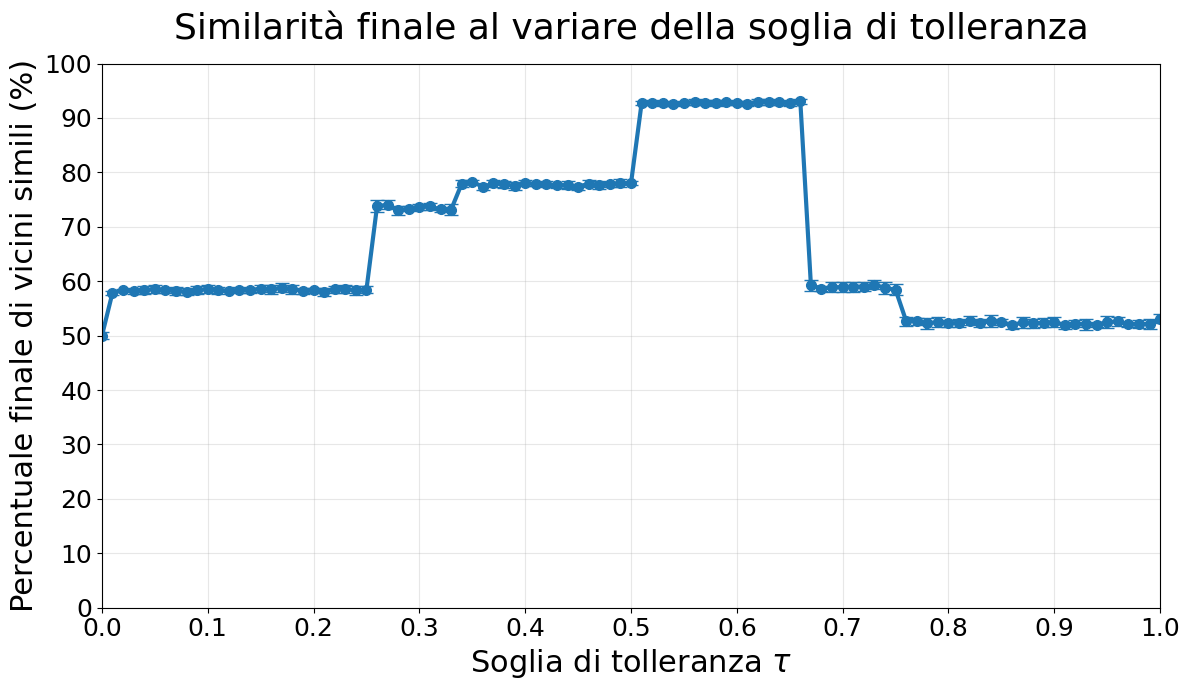

In [35]:
output_folder = "schelling_results/L50/vn/occ0p900"

plot_final_similarity_from_npz(output_folder)

## Snapshots of the Lattice

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def lattice_cmap():
    
    cmap = ListedColormap(["green", "black", "red"])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
    return cmap, norm


def plot_lattice_snapshot(
    grid,
    title=None,
    save_path=None,
    show_fig=True
):
    
    cmap, norm = lattice_cmap()

    plt.figure(figsize=(7, 7))

    plt.imshow(
        grid,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    plt.xticks([])
    plt.yticks([])

    if title is not None:
        plt.title(title, fontsize=24, pad=14)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show_fig:
        plt.show()
    else:
        plt.close()
        
        
def export_lattice_snapshots_from_npz(
    run_path,
    frame_indices=(0, 1, 2, 5, -1),
    save_dir=None,
    show_fig=True
):

    run_path = Path(run_path)
    data = np.load(run_path, allow_pickle=True)

    if "frames" not in data.files:
        raise KeyError(
            f"Il file {run_path} non contiene 'frames'. "
            "Controlla di aver runnato con save_frames=True."
        )

    frames = data["frames"]

    if len(frames) == 0:
        raise ValueError(
            f"Il file {run_path} contiene frames vuoti. "
            "Probabilmente questa run non è stata salvata con save_frames=True."
        )

    if save_dir is None:
        save_dir = run_path.parent / "snapshots"

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    n_frames = len(frames)

    for idx in frame_indices:

        if idx < 0:
            real_idx = n_frames + idx
        else:
            real_idx = idx

        if real_idx < 0 or real_idx >= n_frames:
            print(f"Frame {idx} non disponibile. Numero totale di frames: {n_frames}")
            continue

        frame = frames[real_idx]

        if real_idx == 0:
            title = "Configurazione iniziale"
        elif real_idx == n_frames - 1:
            title = "Configurazione finale"
        else:
            title = f"Step di aggiornamento {real_idx}"

        save_path = save_dir / f"snapshot_step_{real_idx:03d}.png"

        plot_lattice_snapshot(
            grid=frame,
            title=title,
            save_path=save_path,
            show_fig=show_fig
        )

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_000.png


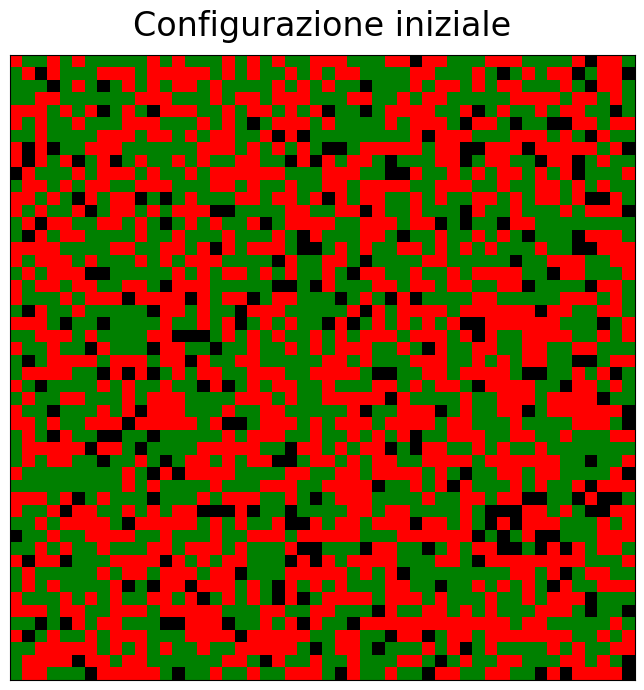

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_001.png


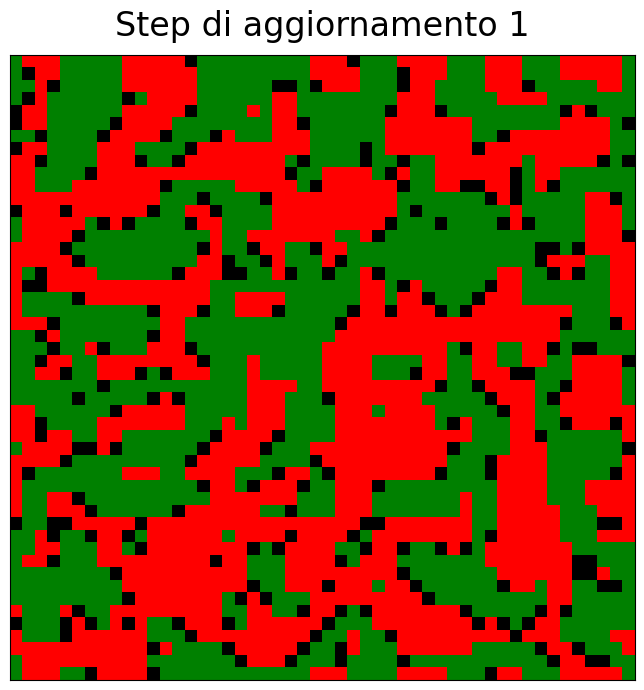

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_002.png


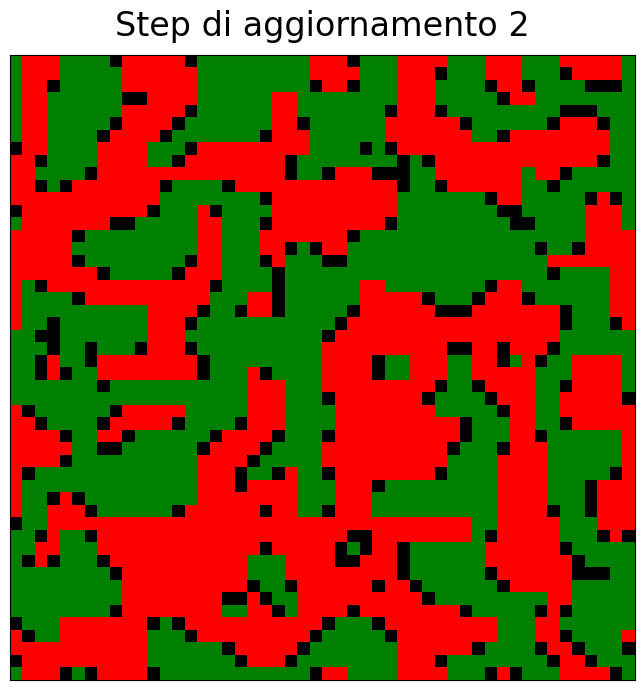

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_004.png


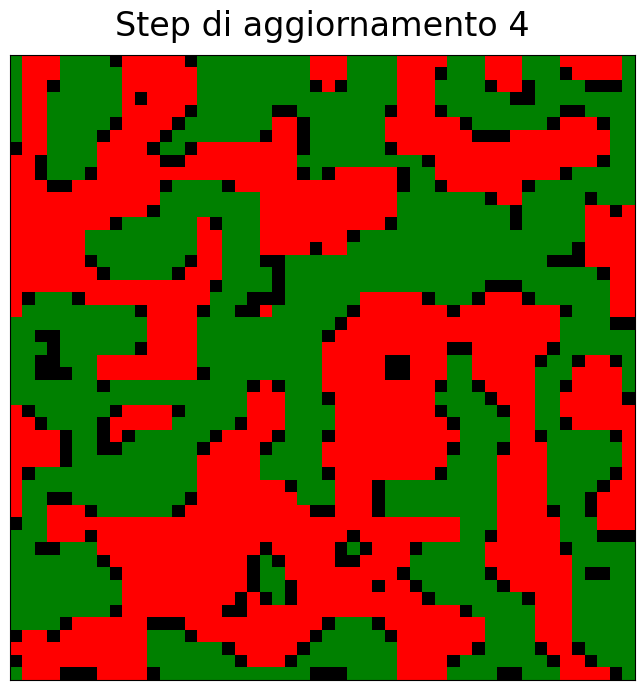

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_005.png


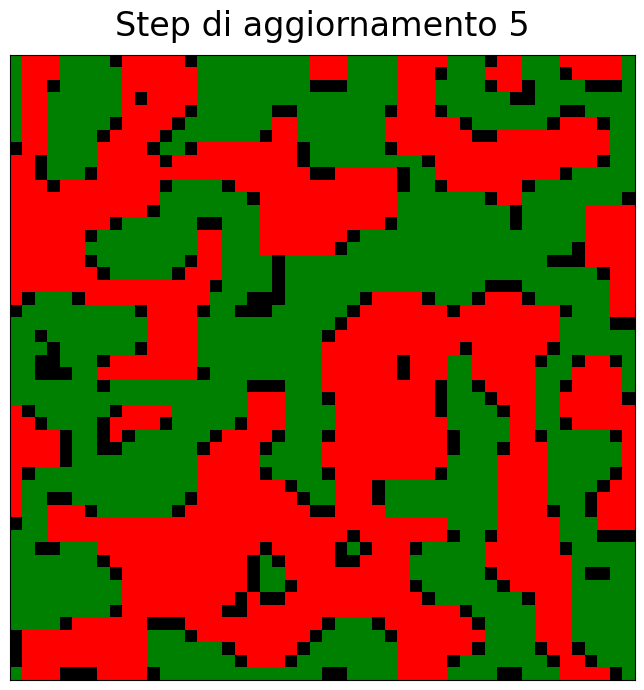

Saved: schelling_results\L50\vn\occ0p900\sw0p510\snapshots\snapshot_step_006.png


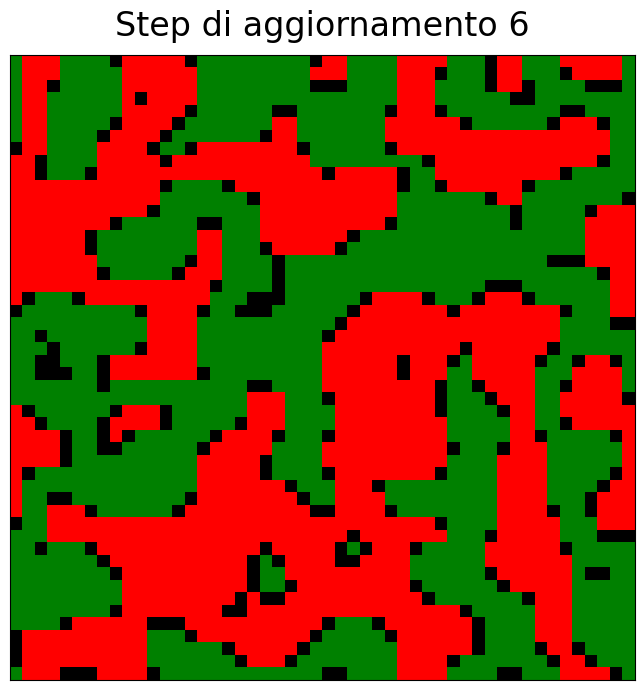

In [47]:
run_path = "schelling_results/L50/vn/occ0p900/sw0p510/r000.npz"

export_lattice_snapshots_from_npz(
    run_path=run_path,
    frame_indices=(0, 1, 2, 4, 5, 6),
    show_fig=True
)